In [3]:
import sys
sys.path.append("..")

In [5]:
from dataclasses import replace
from src.tabular_ml.config import config
from src.tabular_ml.train import run_pipeline
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler


In [6]:
import matplotlib.pyplot as plt
from src.tabular_ml.model import tabular_mlp
from src.tabular_ml.data import load_data, clean, split_data, fit_transform_data, apply_transf


In [7]:
def lr_range_test(model, config, train,start_lr= 1e-7, end_lr = 1.0, epoch_iterations = 200):
    numeric_tensor= torch.tensor(train[config.numeric_cols].values,dtype = torch.float32)
    categorical_tensor = torch.tensor(train[config.categorical_cols].values, dtype= torch.long)

    target_scaler = StandardScaler()
    t_scaled = target_scaler.fit_transform(train[[config.target_col]].values)
    target_tensor = torch.tensor(t_scaled, dtype=torch.float32)

    tensor_dataset = TensorDataset(numeric_tensor, categorical_tensor, target_tensor)
    loader = DataLoader(dataset=tensor_dataset, batch_size=config.batch_size, shuffle=True)

    # From start_lr to end_lr
    growth_factor = (end_lr/start_lr) ** (1/epoch_iterations)
    optimizer = torch.optim.Adam(model.parameters(),lr=start_lr)

    lrs = []
    losses = []
    loss_fn = nn.MSELoss()
    iterations = 0
    while iterations < epoch_iterations:
        for num_b, cat_b, tar_b in loader:
            if iterations >= epoch_iterations:
                break
            optimizer.zero_grad()
            predictions = model(num_b,cat_b)
            batch_loss = loss_fn(predictions,tar_b.view(-1,1))
            batch_loss.backward()
            optimizer.step()

            losses.append(batch_loss.item())
            lrs.append(optimizer.param_groups[0]['lr'])
            optimizer.param_groups[0]['lr'] *= growth_factor
            iterations += 1
    return lrs, losses 
    

In [8]:
df = load_data(config.data_path)
clean_df = clean(df, config)
train, val, test = split_data(clean_df,config)
train_t, scaler, encoders = fit_transform_data(train,config)
c_categories = {col: len(encoders[col].classes_)for col in  config.categorical_cols}
model = tabular_mlp(config,c_categories)

In [9]:
lrs, losses = lr_range_test(model,config, train_t,start_lr=0.0001, end_lr=1.0)

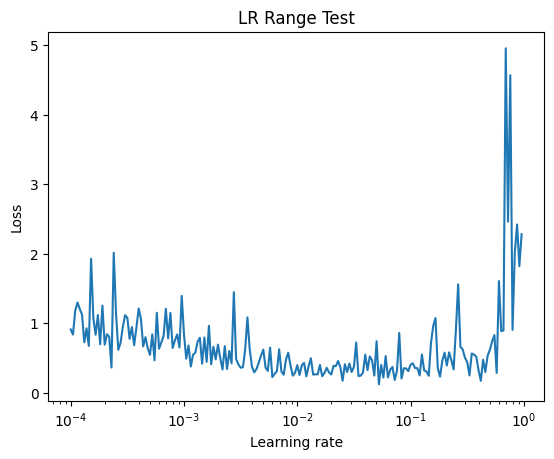

In [10]:
plt.plot(lrs, losses)
plt.xscale("log")
plt.xlabel("Learning rate")
plt.ylabel("Loss")
plt.title("LR Range Test")
plt.show()

In [11]:
print(len(lrs))
print(len(losses))
print(lrs[-1])

200
200
0.9549925860214495


In [12]:
x= [1,2,3,4]
x[1:]

[2, 3, 4]